# Clase 3 · Workflows en LangGraph: orquestar pasos que ya conoces

¿Cómo organizas pasos conocidos (buscar, decidir, repartir, unir) para que sean visibles y comprobables?

**Vas a construir:**
- Un grafo de secuencia (buscar → responder) y otro con routing que sabe abstenerse.
- Un grafo paralelo que espera a sus dos ramas antes de unir.
- Un orquestador que crea tantas tareas como pida un plan, con `Send` y un *reducer*.

**Necesitas:** clase 2 (y ruta 1). Modo offline por defecto; live si el docente lo activa.

**Recorrido:**
- De Python puro a LangGraph: qué ganas
- Estado y nodos
- Secuencia y su dibujo
- Routing: responder o abstenerse; ver los pasos en vivo
- ☕ Pausa
- ✏️ Tu turno: tu propia regla de routing, conectada a un grafo
- Paralelo fijo con barrera de unión
- Orquestador con `Send` y reducer
- ☕ Pausa
- ✏️ Tu turno: diseñar el plan de una actividad
- Cierre: proyecto, ticket y glosario

## De Python puro a LangGraph
En la ruta 1 hiciste cadenas, routing y paralelismo con funciones de Python. Aquí hacemos
**lo mismo** con LangGraph. ¿Para qué cambiar? Porque ganas:

| Ganas | Qué significa |
|---|---|
| Estado | Un diccionario que viaja entre pasos, con campos declarados |
| Dibujo | El grafo se dibuja solo: ves la arquitectura |
| Streaming | Puedes mirar cada paso mientras ocurre |
| Checkpoints | Guardar el estado para recordar (clase 4) o pausar y continuar (clase 6) |

Un **grafo** tiene **nodos** (pasos) y **aristas** (flechas: qué paso sigue).
Ojo: todo lo de hoy son *workflows*: el código decide el camino, no un modelo.

In [4]:
from henry_agents.agentic import mostrar_grafo
from henry_agents.config import configure
from henry_agents.cultural import SearchResult, compose, search_catalog
from henry_agents.practica import comprobar, confirmar, ver_solucion

MODE = configure()
print("Modo:", MODE)

Modo: offline


## Estado y nodos
El **estado** es el diccionario compartido. Lo declaramos con `TypedDict`.

🐍 **Python nuevo:** `class EstadoRAG(TypedDict, total=False)` describe qué claves puede
tener el diccionario y de qué tipo. `total=False` significa "no todas tienen que existir
desde el principio". Es una descripción para el editor y para LangGraph: **no valida** datos
como Pydantic.

In [5]:
from typing import TypedDict


class EstadoRAG(TypedDict, total=False):
    query: str  # la pregunta
    universe: str  # la colección
    evidence: dict  # lo que encontró la búsqueda
    answer: str  # la respuesta
    sources: list[str]  # los IDs citados
    status: str  # "answered" o "abstained"

Un **nodo** es una función que recibe el estado y devuelve **solo lo que cambia**. LangGraph
mezcla esa actualización con el estado. No hace falta copiar todo el diccionario.

In [6]:
def nodo_buscar(estado):
    encontrado = search_catalog(estado["query"], universe=estado.get("universe", "todos"), top_k=2)
    return {"evidence": encontrado.model_dump()}


def nodo_responder(estado):
    evidencia = SearchResult.model_validate(estado["evidence"])
    respuesta = compose(evidencia, MODE)  # offline: extractos; live: GPT-6 con citas validadas
    estado_final = "answered" if respuesta.source_ids else "abstained"
    return {"answer": respuesta.text, "sources": respuesta.source_ids, "status": estado_final}


print("buscar devuelve las claves:", list(nodo_buscar({"query": "investigación", "universe": "batman"})))

buscar devuelve las claves: ['evidence']


🔍 **Observa:** `nodo_buscar` solo devuelve `evidence`. La pregunta (`query`) sigue en el
estado sin que nadie la copie.

## Secuencia: buscar → responder
🔮 **Predice:** después de ejecutar el grafo, ¿qué claves tendrá el estado final?

In [7]:
from langgraph.graph import END, START, StateGraph

# 1) Crear el grafo con la forma del estado.
secuencia = StateGraph(EstadoRAG)
# 2) Registrar los nodos: un nombre y la función que se ejecuta.
secuencia.add_node("buscar", nodo_buscar)
secuencia.add_node("responder", nodo_responder)
# 3) Dibujar el mapa: qué paso sigue a cuál.
secuencia.add_edge(START, "buscar")
secuencia.add_edge("buscar", "responder")
secuencia.add_edge("responder", END)
# 4) Compilar: revisa el mapa y lo deja listo.
app_secuencial = secuencia.compile()
# 5) Ejecutar con un estado inicial.
resultado = app_secuencial.invoke({"query": "investigación", "universe": "batman"})
print("Claves finales:", sorted(resultado))
print("Fuentes:", resultado["sources"])
confirmar(resultado["query"] == "investigación", "La pregunta debía conservarse en el estado")

Claves finales: ['answer', 'evidence', 'query', 'sources', 'status', 'universe']
Fuentes: ['BAT-01', 'BAT-03']


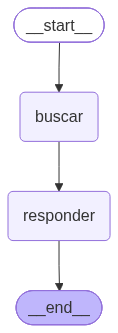

In [8]:
mostrar_grafo(app_secuencial)

🔍 **Observa:** el dibujo coincide con las aristas que escribiste. `__start__` y `__end__`
son los nombres internos de `START` y `END`: la entrada y la salida del grafo. Con Internet
ves una imagen; sin Internet, un dibujo en texto. Ambos dicen lo mismo.

## Routing: responder o abstenerse
La secuencia siempre responde, aunque no haya evidencia. Agregamos una decisión:

```text
               ┌─ hay fichas ──→ responder ──→ END
START → buscar ┤
               └─ no hay ──────→ abstenerse ─→ END
```

Una **arista condicional** llama a una función que devuelve el **nombre** del siguiente nodo.

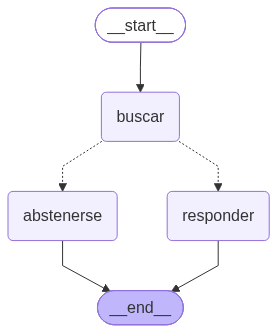

In [9]:
def nodo_abstenerse(estado):
    return {"answer": "No hay evidencia en el catálogo.", "sources": [], "status": "abstained"}


def elegir_ruta(estado):
    return "responder" if estado["evidence"]["hits"] else "abstenerse"


constructor = StateGraph(EstadoRAG)
constructor.add_node("buscar", nodo_buscar)
constructor.add_node("responder", nodo_responder)
constructor.add_node("abstenerse", nodo_abstenerse)
constructor.add_edge(START, "buscar")
constructor.add_conditional_edges("buscar", elegir_ruta, ["responder", "abstenerse"])
constructor.add_edge("responder", END)
constructor.add_edge("abstenerse", END)
app = constructor.compile()
mostrar_grafo(app)

🔮 **Predice:** para "vacuna marciana", ¿qué nodos se ejecutan, en orden?

`stream(..., stream_mode="updates")` muestra **cada paso al terminar**: el nombre del nodo
y lo que cambió. Es la forma de "ver por dentro" un grafo.

In [24]:
pasos = []
for paso in app.stream({"query": "Marciano", "universe": "todos"}, stream_mode="updates"):
    nombre_nodo = list(paso)[0]
    pasos.append(nombre_nodo)
    print("▶", nombre_nodo, "→ cambió:", list(paso[nombre_nodo]))
confirmar(pasos == ["buscar", "abstenerse"], "Sin evidencia, el grafo debía ir a abstenerse")

▶ buscar → cambió: ['evidence']
▶ abstenerse → cambió: ['answer', 'sources', 'status']


In [25]:
con_evidencia = app.invoke({"query": "cooperación", "universe": "chavo"})
print("Estado:", con_evidencia["status"], "| fuentes:", con_evidencia["sources"])
if MODE == "offline":
    confirmar(con_evidencia["sources"] == ["CHA-01"], "Cooperación en chavo debía citar CHA-01")

Estado: answered | fuentes: ['CHA-01']


🔍 **Observa:** la rama vacía **no llama al modelo**: ahorra costo y evita inventos. La
regla de routing es código simple porque "¿hay fichas?" no necesita interpretar lenguaje.

## ☕ Pausa

## ✏️ Tu turno 1 · Tu propia regla de routing
El encargo cambia: si la búsqueda trae **solo una** ficha, hay que avisar "evidencia
escasa". Completa `mi_ruta` para que devuelva:
- `"abstenerse"` si no hay fichas;
- `"advertir"` si hay exactamente una;
- `"responder"` si hay dos o más.

`len(estado["evidence"]["hits"])` cuenta las fichas. Después vas a conectar tu regla a un grafo.

In [26]:
def mi_ruta(estado):
    cantidad = len(estado["evidence"]["hits"])  # la usarás tú
    return None  # ✏️ completa aquí con if / elif / else

In [13]:
def prueba(n):
    return mi_ruta({"evidence": {"hits": [{}] * n}})


mis_rutas = {0: prueba(0), 1: prueba(1), 3: prueba(3)}
comprobar(
    mis_rutas == {0: "abstenerse", 1: "advertir", 3: "responder"},
    "Tu regla cubre los tres casos.",
    f"Con 0, 1 y 3 fichas tu función devolvió {mis_rutas}. ¿Cuál no coincide con la consigna "
    "(revisa también la ortografía exacta del texto)?",
)

🔁 Todavía no. Pista: Con 0, 1 y 3 fichas tu función devolvió {0: None, 1: None, 3: None}. ¿Cuál no coincide con la consigna (revisa también la ortografía exacta del texto)?


False

Ahora tu regla decide en un grafo de verdad. Agregamos un nodo `advertir` que responde,
pero avisando que la evidencia es escasa.

🔮 **Predice:** "cooperación" en chavo trae una sola ficha. ¿Qué nodos se ejecutan?

In [14]:
def nodo_advertir(estado):
    respuesta = nodo_responder(estado)
    return {**respuesta, "answer": "⚠️ Evidencia escasa (una ficha). " + respuesta["answer"], "status": "warned"}


if mis_rutas == {0: "abstenerse", 1: "advertir", 3: "responder"}:
    con_aviso = StateGraph(EstadoRAG)
    for nombre_nodo, funcion in [
        ("buscar", nodo_buscar),
        ("responder", nodo_responder),
        ("advertir", nodo_advertir),
        ("abstenerse", nodo_abstenerse),
    ]:
        con_aviso.add_node(nombre_nodo, funcion)
    con_aviso.add_edge(START, "buscar")
    con_aviso.add_conditional_edges("buscar", mi_ruta, ["responder", "advertir", "abstenerse"])
    for final in ["responder", "advertir", "abstenerse"]:
        con_aviso.add_edge(final, END)
    app_con_aviso = con_aviso.compile()
    recorrido = [list(p)[0] for p in app_con_aviso.stream({"query": "cooperación", "universe": "chavo"}, stream_mode="updates")]
    print("Recorrido:", recorrido)
    comprobar(recorrido == ["buscar", "advertir"], "Una sola ficha llevó a advertir.", "¿Cuántas fichas trajo la búsqueda?")
else:
    print("🔁 Completa mi_ruta para conectarla al grafo.")

🔁 Completa mi_ruta para conectarla al grafo.


In [15]:
ver_solucion("03_ruta_advertir")

# Solución: 03_ruta_advertir

"""Clase 3 · Tu turno 1: routing con tres salidas según cuántas fichas hay, conectado a un grafo."""

from typing import TypedDict

from langgraph.graph import END, START, StateGraph

from henry_agents.config import configure
from henry_agents.cultural import SearchResult, compose, search_catalog
from henry_agents.practica import confirmar

MODE = configure()


def mi_ruta(estado):
    cantidad = len(estado["evidence"]["hits"])
    if cantidad == 0:
        return "abstenerse"
    elif cantidad == 1:
        return "advertir"
    else:
        return "responder"


class EstadoRAG(TypedDict, total=False):
    query: str
    universe: str
    evidence: dict
    answer: str
    sources: list[str]
    status: str


def nodo_buscar(estado):
    return {"evidence": search_catalog(estado["query"], universe=estado.get("universe", "todos"), top_k=2).model_dump()}


def nodo_responder(estado):
    respuesta = compose(SearchResult.model_validate(estado["evidence"]), 

## Paralelo fijo con barrera de unión
Dos búsquedas **independientes** (Batman y Fantásticos) pueden correr al mismo tiempo.

```text
       ┌─ batman ──────┐
START ─┤               ├─ unir ─→ END
       └─ fantasticos ─┘
```

Cada rama escribe **su propio campo** para no pisarse. La arista desde la lista
`["batman", "fantasticos"]` es una **barrera**: `unir` espera a las dos.

Informe conjunto: ['BAT-02', 'FAN-02']


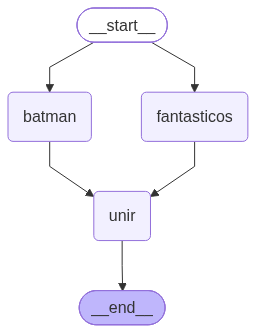

In [16]:
class EstadoParalelo(TypedDict, total=False):
    query: str
    batman: list[str]
    fantasticos: list[str]
    sources: list[str]


def rama_batman(estado):
    return {"batman": [h.id for h in search_catalog(estado["query"], universe="batman", top_k=1).hits]}


def rama_fantasticos(estado):
    hits = search_catalog(estado["query"], universe="fantasticos", top_k=1).hits
    return {"fantasticos": [h.id for h in hits]}


def unir(estado):
    return {"sources": sorted(estado["batman"] + estado["fantasticos"])}


paralelo = StateGraph(EstadoParalelo)
paralelo.add_node("batman", rama_batman)
paralelo.add_node("fantasticos", rama_fantasticos)
paralelo.add_node("unir", unir)
paralelo.add_edge(START, "batman")
paralelo.add_edge(START, "fantasticos")
paralelo.add_edge(["batman", "fantasticos"], "unir")  # barrera: espera a ambas
paralelo.add_edge("unir", END)
app_paralela = paralelo.compile()
informe = app_paralela.invoke({"query": "herramientas"})
print("Informe conjunto:", informe["sources"])
confirmar(informe["sources"] == ["BAT-02", "FAN-02"], "Herramientas debía unir BAT-02 y FAN-02")
mostrar_grafo(app_paralela)

🔍 **Observa:** cambia la consulta a "investigación" y vuelve a ejecutar: Batman encuentra
fichas y Fantásticos también (FAN-01 menciona la palabra). Si una rama vuelve vacía, `unir`
no debe inventar nada para "rellenar".

## Orquestador con `Send` y reducer
En el paralelo fijo sabías cuántas ramas había. Ahora un **plan** dice qué colecciones
consultar: pueden ser una, dos o cuatro. `Send("worker", datos)` crea **una tarea por
colección**, cada una con su pequeño estado.

```text
START → planificar → Send(worker) × N → reunir → END
```

Problema: todos los workers escriben en el **mismo** campo `parts`. Un **reducer** (la
regla que dice cómo juntar dos escrituras en el mismo campo) lo resuelve.

🐍 **Python nuevo:** `Annotated[list[dict], operator.add]` se lee "una lista de diccionarios
que se junta sumando listas". `operator.add([a], [b])` da `[a, b]`.

In [17]:
import operator
from typing import Annotated

from langgraph.types import Send

print("Así junta el reducer:", operator.add([{"universe": "chavo"}], [{"universe": "fantasticos"}]))


class EstadoEquipo(TypedDict, total=False):
    query: str
    universes: list[str]
    parts: Annotated[list[dict], operator.add]  # cada worker AGREGA su parte
    summary: str

Así junta el reducer: [{'universe': 'chavo'}, {'universe': 'fantasticos'}]


El plan se **valida antes de repartir**: colecciones desconocidas se rechazan y las
repetidas se eliminan (`set`). Así un plan mal escrito no crea tareas de más.

In [18]:
PERMITIDAS = {"batman", "fantasticos", "chavo", "canciones"}


def planificar(estado):
    pedidas = estado["universes"]
    if not pedidas:
        raise ValueError("El plan está vacío")
    desconocidas = sorted(set(pedidas) - PERMITIDAS)
    if desconocidas:
        raise ValueError(f"Colecciones desconocidas: {desconocidas}. Usa: {sorted(PERMITIDAS)}")
    return {"universes": sorted(set(pedidas))}


def repartir(estado):
    return [Send("worker", {"query": estado["query"], "universe": u}) for u in estado["universes"]]


def worker(estado):
    hits = search_catalog(estado["query"], universe=estado["universe"], top_k=1).hits
    return {"parts": [{"universe": estado["universe"], "ids": [h.id for h in hits]}]}


def reunir(estado):
    partes = sorted(estado["parts"], key=lambda parte: parte["universe"])
    return {"summary": "\n".join(f"{p['universe']}: {p['ids']}" for p in partes)}


equipo = StateGraph(EstadoEquipo)
equipo.add_node("planificar", planificar)
equipo.add_node("worker", worker)
equipo.add_node("reunir", reunir)
equipo.add_edge(START, "planificar")
equipo.add_conditional_edges("planificar", repartir, ["worker"])  # aquí nacen N tareas
equipo.add_edge("worker", "reunir")
equipo.add_edge("reunir", END)
app_equipo = equipo.compile()

🐍 **Python nuevo:** `key=lambda parte: parte["universe"]` es una función de una línea que
le dice a `sorted` "ordena por la colección". Ordenamos porque los workers pueden terminar
en cualquier orden.

🔮 **Predice:** con `["fantasticos", "chavo", "chavo"]`, ¿cuántos workers se crean?

In [19]:
resultado_equipo = app_equipo.invoke(
    {"query": "cooperación", "universes": ["fantasticos", "chavo", "chavo"], "parts": []}
)
print(resultado_equipo["summary"])
confirmar(len(resultado_equipo["parts"]) == 2, "La colección repetida no debía crear otro worker")
try:
    app_equipo.invoke({"query": "equipo", "universes": ["internet"], "parts": []})
except ValueError as error:
    print("Plan rechazado:", error)

chavo: ['CHA-01']
fantasticos: ['FAN-01']
Plan rechazado: Colecciones desconocidas: ['internet']. Usa: ['batman', 'canciones', 'chavo', 'fantasticos']


🔍 **Observa:** dos workers (chavo se deduplicó) y un plan con "internet" se rechaza
**antes** de crear tareas. Este patrón es la base de los equipos de agentes de las clases 5 y 7.

## ☕ Pausa

## ✏️ Tu turno 2 · Diseña el plan de una actividad
El Centro Cultural quiere una actividad de **cooperación** con música. Arma un plan con
**todas** las colecciones que tengan algo sobre cooperación, y **ninguna** que vuelva vacía
(cada worker vacío es una búsqueda desperdiciada).

Cómo hacerlo: prueba primero con las cuatro colecciones, mira el resumen y quita las que
devuelvan `[]`. Escribe los nombres en minúscula y sin tilde, como en `PERMITIDAS`.
🔮 Antes: ¿cuántas partes crees que quedarán?

In [20]:
mi_plan = {
    "query": "cooperación",
    "universes": None,  # ✏️ completa aquí: la lista de colecciones de tu plan
    "parts": [],
}
mi_prediccion_partes = None  # ✏️ completa aquí: cuántas partes esperas

In [21]:
from henry_agents.practica import revisar

mi_resultado = {"parts": []}
if mi_plan["universes"] is not None:
    try:
        mi_resultado = app_equipo.invoke(mi_plan)
        print(mi_resultado["summary"])
    except ValueError as error:
        print("⛔ El plan fue rechazado antes de crear tareas:", error)
vacias = [p["universe"] for p in mi_resultado["parts"] if not p["ids"]]
if vacias:
    print(f"🔁 Estas colecciones volvieron vacías: {vacias}. ¿Hacen falta en el plan?")
if mi_plan["universes"] is None:
    print("🔁 Completa mi_plan['universes'] con una lista de colecciones.")
else:
    revisar("03_plan_cooperacion", sorted({p["universe"] for p in mi_resultado["parts"]}))
if mi_prediccion_partes is not None and mi_resultado["parts"]:
    print(f"Predijiste {mi_prediccion_partes} partes; hubo {len(mi_resultado['parts'])}.")

🔁 Completa mi_plan['universes'] con una lista de colecciones.


In [22]:
ver_solucion("03_plan_cooperacion")

# Solución: 03_plan_cooperacion

"""Clase 3 · Tu turno 2: el plan de una actividad de cooperación, sin workers vacíos."""

import operator
from typing import Annotated, TypedDict

from langgraph.graph import END, START, StateGraph
from langgraph.types import Send

from henry_agents.cultural import search_catalog
from henry_agents.practica import confirmar

PERMITIDAS = {"batman", "fantasticos", "chavo", "canciones"}


class EstadoEquipo(TypedDict, total=False):
    query: str
    universes: list[str]
    parts: Annotated[list[dict], operator.add]
    summary: str


def planificar(estado):
    desconocidas = sorted(set(estado["universes"]) - PERMITIDAS)
    if not estado["universes"] or desconocidas:
        raise ValueError(f"Plan inválido: {desconocidas or 'vacío'}")
    return {"universes": sorted(set(estado["universes"]))}


def repartir(estado):
    return [Send("worker", {"query": estado["query"], "universe": u}) for u in estado["universes"]]


def worker(estado):
    hits = searc

## 🧱 Proyecto · Paso 3: el flujo fijo del asistente
Tu asistente ya busca (clase 1) y responde con fuentes (clase 2). Hoy le das forma de grafo:
1. Construye el grafo buscar → responder o abstenerse (puedes partir del de esta clase).
2. Dibújalo con `mostrar_grafo`.
3. Prueba las dos rutas con `stream_mode="updates"`: una pregunta con evidencia y otra sin.

**Evidencia que guardas** (en tu copia de `proyectos/asistente_archivo/mi_entrega.md`, sección
Paso 3): el grafo dibujado y las dos rutas probadas.

## 🎟️ Ticket de salida
1. ¿Qué devuelve un nodo: el estado completo o solo lo que cambia?
2. ¿Por qué cada rama del paralelo escribe en un campo distinto?
3. ¿Qué problema resuelve el reducer cuando varios workers escriben `parts`?

## 📖 Glosario de hoy
| Término | En una frase |
|---|---|
| Grafo | Mapa de pasos (nodos) unidos por flechas (aristas) |
| Estado | Diccionario compartido que viaja entre los nodos |
| Nodo | Función que recibe el estado y devuelve solo lo que cambia |
| Arista condicional | Flecha que elige el siguiente nodo según una función |
| Streaming | Ver cada paso del grafo mientras ocurre |
| Barrera de unión | Nodo que espera a varias ramas antes de seguir |
| `Send` | Crea una tarea con su propio estado pequeño, una por elemento del plan |
| Reducer | Regla para juntar varias escrituras en el mismo campo |

## Límites de lo que hicimos
- El código decide todos los caminos: todavía no hay un agente que elija (clase 4).
- En una demo local el paralelo no se nota más rápido: el beneficio aparece con pasos lentos,
  como llamadas a modelos o a servicios externos.
- `operator.add` junta listas pero no elimina repetidos: por eso deduplicamos el plan.